####

In [3]:
%pip install xlrd pandas matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Load dataset files into individual DataFrames
try:
    df_csv = pd.read_csv('sales_data_sample.csv', encoding='ISO-8859-1')
    df_excel = pd.read_excel('sales_data_sample.xls')  # or .xlsx
    df_json = pd.read_json('sales_data_sample.json')
    
    print("Files loaded successfully.")
except Exception as e:
    print(f"Error loading files: {e}")

Files loaded successfully.


In [5]:
def inspect_dataframe(df, name="DataFrame"):
    print(f"=== Exploration for {name} ===")
    print(f"Shape: {df.shape}")
    print("\nData Types & Info:")
    df.info()
    print("\nMissing Values:")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    print("\nDuplicate Rows:", df.duplicated().sum())
    print("-" * 50)

# Inspect each dataset
inspect_dataframe(df_csv, "CSV File")
inspect_dataframe(df_excel, "Excel File")
inspect_dataframe(df_json, "JSON File")

=== Exploration for CSV File ===
Shape: (2823, 25)

Data Types & Info:
<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   str    
 6   STATUS            2823 non-null   str    
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   str    
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   str    
 13  CUSTOMERNAME      2823 non-null   str    
 14  PHONE             2823 non-null   str    
 15  ADDRESSLINE1      2823 non-nu

In [6]:
# Clean column headers for each DataFrame before merging
for df in [df_csv, df_excel, df_json]:
    df.columns = df.columns.str.strip().str.upper()

# Combine all datasets into a single unified DataFrame
master_df = pd.concat([df_csv, df_excel, df_json], ignore_index=True)

# 1. Remove duplicate entries
initial_count = len(master_df)
master_df.drop_duplicates(inplace=True)
print(f"Removed {initial_count - len(master_df)} duplicate rows.")

# 2. Handle missing values
# Fill numerical missing values with median or 0 where applicable
num_cols = master_df.select_dtypes(include=[np.number]).columns
master_df[num_cols] = master_df[num_cols].fillna(master_df[num_cols].median())

# Fill categorical missing values with 'Unknown'
cat_cols = master_df.select_dtypes(include=['object']).columns
master_df[cat_cols] = master_df[cat_cols].fillna('Unknown')

Removed 593 duplicate rows.


/tmp/ipykernel_21105/1686824339.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = master_df.select_dtypes(include=['object']).columns


In [7]:
# 1. Convert Date Column to Datetime Format
if 'ORDERDATE' in master_df.columns:
    master_df['ORDERDATE'] = pd.to_datetime(master_df['ORDERDATE'], errors='coerce')
    
    # Extract temporal components
    master_df['YEAR'] = master_df['ORDERDATE'].dt.year
    master_df['MONTH'] = master_df['ORDERDATE'].dt.month_name()
    master_df['YEAR_MONTH'] = master_df['ORDERDATE'].dt.to_period('M')

# 2. Derive calculated total sales metric
if 'QUANTITYORDERED' in master_df.columns and 'PRICEEACH' in master_df.columns:
    master_df['TOTAL_SALES'] = master_df['QUANTITYORDERED'] * master_df['PRICEEACH']
elif 'SALES' in master_df.columns:
    master_df['TOTAL_SALES'] = master_df['SALES']

# 3. Categorize order size based on quantity
if 'QUANTITYORDERED' in master_df.columns:
    master_df['ORDER_SIZE_CATEGORY'] = pd.cut(
        master_df['QUANTITYORDERED'],
        bins=[0, 20, 40, np.inf],
        labels=['Small', 'Medium', 'Large']
    )

In [8]:
print("=== DESCRIPTIVE STATISTICS ===")
print(master_df[['QUANTITYORDERED', 'PRICEEACH', 'TOTAL_SALES']].describe())

# Calculate Core Metrics
total_revenue = master_df['TOTAL_SALES'].sum()
avg_order_value = master_df.groupby('ORDERNUMBER')['TOTAL_SALES'].sum().mean()
total_orders = master_df['ORDERNUMBER'].nunique()

print("\n=== KEY PERFORMANCE INDICATORS ===")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value (AOV): ${avg_order_value:,.2f}")

# Aggregation by Product Category
category_sales = master_df.groupby('PRODUCTLINE').agg(
    Total_Revenue=('TOTAL_SALES', 'sum'),
    Average_Price=('PRICEEACH', 'mean'),
    Total_Units_Sold=('QUANTITYORDERED', 'sum')
).sort_values(by='Total_Revenue', ascending=False)

print("\n=== SALES BY PRODUCT LINE ===")
print(category_sales)

=== DESCRIPTIVE STATISTICS ===
       QUANTITYORDERED    PRICEEACH  TOTAL_SALES
count      7876.000000  7876.000000  7876.000000
mean         35.153885    83.630973  2941.018441
std           9.765696    20.248462  1109.493612
min           6.000000    26.880000   482.130000
25%          27.000000    68.710000  2100.000000
50%          35.000000    95.800000  2800.000000
75%          43.000000   100.000000  3756.000000
max          97.000000   100.000000  9048.160000

=== KEY PERFORMANCE INDICATORS ===
Total Revenue: $23,163,461.24
Total Orders: 307
Average Order Value (AOV): $75,451.01

=== SALES BY PRODUCT LINE ===
                  Total_Revenue  Average_Price  Total_Units_Sold
PRODUCTLINE                                                     
Classic Cars         8347993.70      87.294055             95619
Vintage Cars         4567643.80      77.949384             58697
Motorcycles          2723319.32      83.034522             32721
Trucks and Buses     2675343.00      87.606387    

/tmp/ipykernel_21105/2594311458.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_21105/2594311458.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


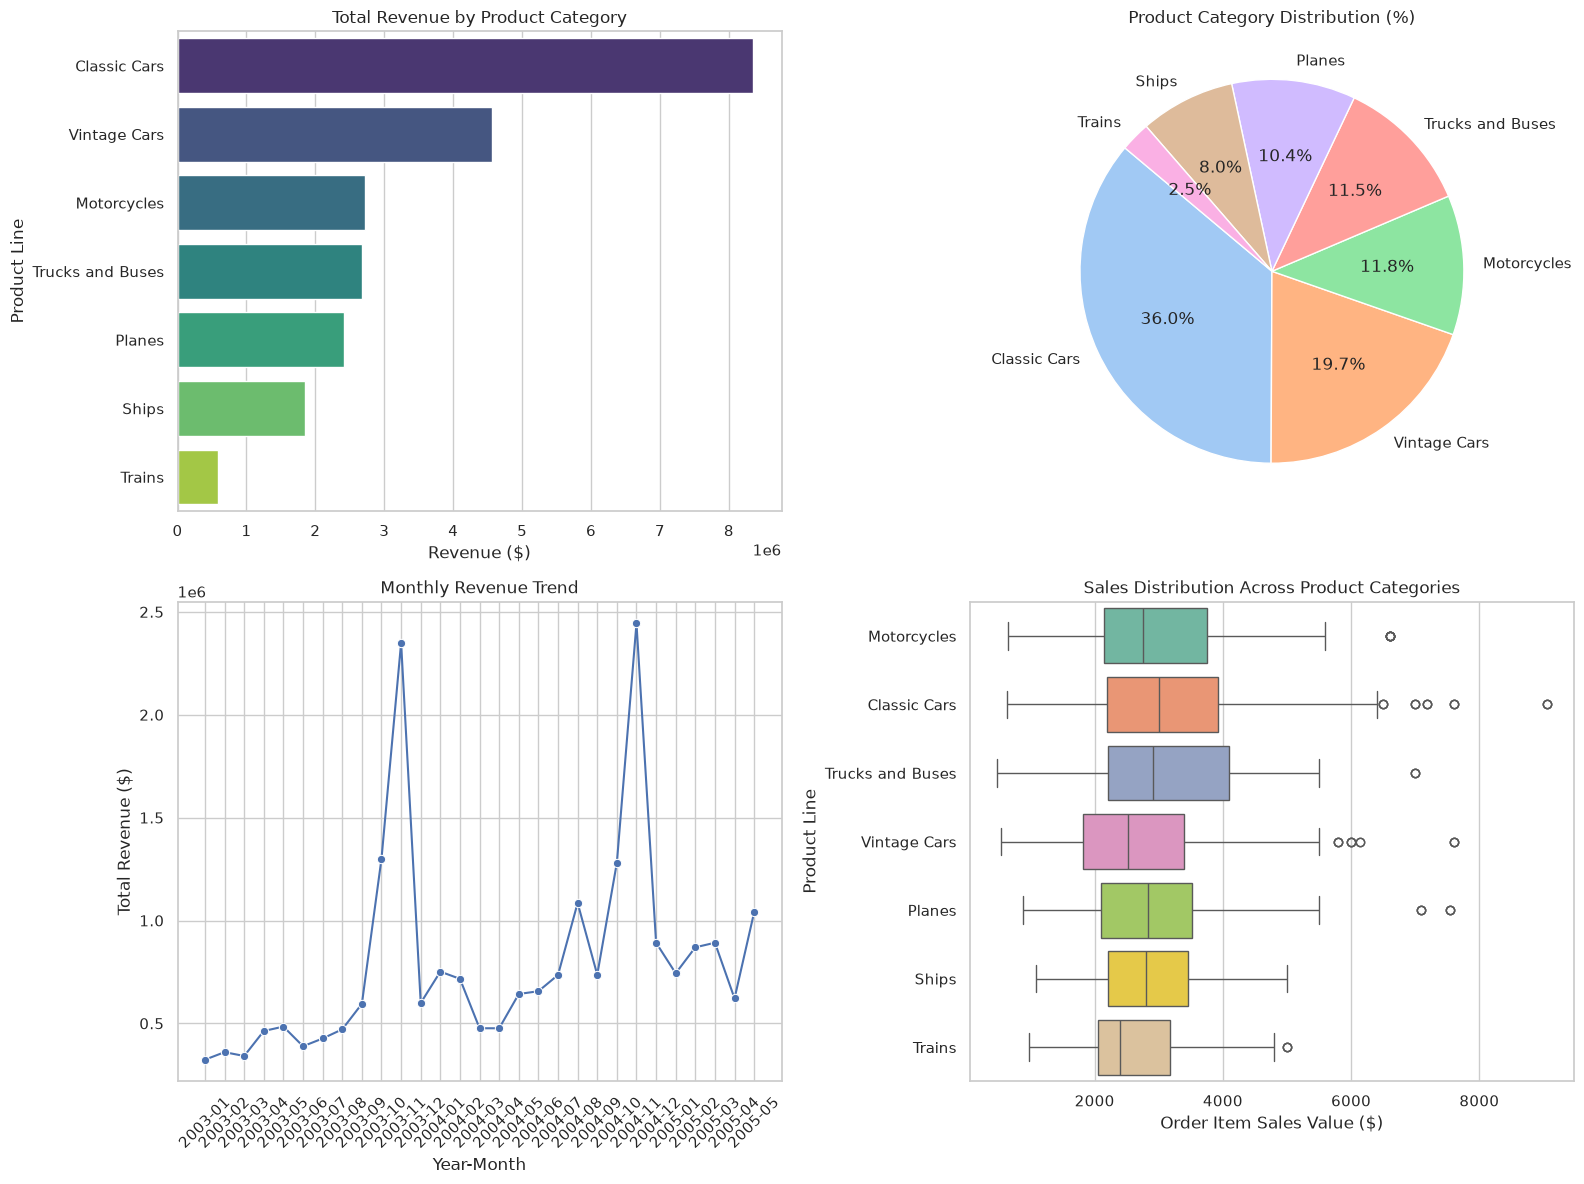

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Total Revenue by Product Line (Bar Chart)
sns.barplot(
    data=category_sales.reset_index(),
    x='Total_Revenue',
    y='PRODUCTLINE',
    palette='viridis',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Total Revenue by Product Category')
axes[0, 0].set_xlabel('Revenue ($)')
axes[0, 0].set_ylabel('Product Line')

# Chart 2: Product Line Share (Pie Chart)
axes[0, 1].pie(
    category_sales['Total_Revenue'],
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')
)
axes[0, 1].set_title('Product Category Distribution (%)')

# Chart 3: Monthly Sales Trend (Line Chart)
monthly_trend = master_df.groupby('YEAR_MONTH')['TOTAL_SALES'].sum().reset_index()
monthly_trend['YEAR_MONTH'] = monthly_trend['YEAR_MONTH'].astype(str)

sns.lineplot(
    data=monthly_trend,
    x='YEAR_MONTH',
    y='TOTAL_SALES',
    marker='o',
    color='b',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Monthly Revenue Trend')
axes[1, 0].set_xlabel('Year-Month')
axes[1, 0].set_ylabel('Total Revenue ($)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Chart 4: Order Price Distribution Across Categories (Box Plot)
sns.boxplot(
    data=master_df,
    x='TOTAL_SALES',
    y='PRODUCTLINE',
    palette='Set2',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Sales Distribution Across Product Categories')
axes[1, 1].set_xlabel('Order Item Sales Value ($)')
axes[1, 1].set_ylabel('Product Line')

plt.tight_layout()
plt.show()